## **FOLPS Run Demo (Numpy)**
This notebook demonstrates how to use FOLPS to compute the **power spectrum** and **bispectrum**.  

### Set the backend
Select the backend (`numpy` or `jax`). In this notebook, we use `numpy`.  
For an example with `jax`, see [link]. 

In [1]:
import isitgr, inspect
print(inspect.getfile(isitgr))


/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260210-1.0.0/conda/lib/python3.12/site-packages/isitgr/__init__.py


In [4]:
import os

# Select the backend before importing folps.py
os.environ["FOLPS_BACKEND"] = "numpy"  #'numpy' or 'jax'
# import folps
import numpy as np
import sys
sys.path.insert(0,'/global/homes/p/prakharb/FOLPS_JAX')
from folps import *
# import folps, inspect
print(inspect.getfile(folps))

/global/homes/p/prakharb/FOLPS_JAX/folps/folps.py


### Linear power spectrum  
The linear power spectrum can be computed using CLASS. If CLASS is not available, it will be loaded automatically instead.  
Additionally, some cosmological parameters must be provided as input (see `kwargs`).  

In [5]:
use_class = False
try:
    # try to import the CLASS-based runner; if Class isn't installed it will load a precomputed file
    from cosmo_class import run_class
    from classy import Class as _Class  # noqa: F401
except Exception:
    use_class = False

if use_class:
    classy  = run_class(h = 0.6711, ombh2 = 0.022, omch2 = 0.122, omnuh2 = 0.0006442, 
                        As = 2e-9, ns = 0.965, z = 0.3, z_scale=[0.97],
                        N_ur = 2.0328,
                        khmin = 0.0001, khmax = 2.0, nbk = 1000, spectra = 'cb')
else:
    # Fallback: read precomputed k, pk from the repository file (do not create a cosmo object)
    data_path = 'inputpkT.txt'
    k_arr, pk_arr = np.loadtxt(data_path, unpack=True)

    # Provide k and pk only
    classy = {'k': k_arr, 'pk': pk_arr}

# kwargs used by other parts of the notebook
kwargs = {'z': 0.3,
          'h': 0.6711,
          'Omega_m': 0.3211636237981114,
          'f0': np.float64(0.6880638641959066),
          'fnu': 0.004453689063655854}

### Matrices  
Compute the matrices required for the non-linear power spectrum.  
**They do not depend on cosmology**, so they are **calculated only once.**  

In [6]:
matrix = MatrixCalculator()
mmatrices = matrix.get_mmatrices()

Calculating matrices (no save path specified)


### Non-linear Power Spectrum
Computation of the non-linear power spectrum.  
In the `NonLinearPowerSpectrumCalculator` class, you can choose between the `fk` or `EdS` kernel.

In [7]:
%%time
nonlinear = NonLinearPowerSpectrumCalculator(mmatrices=mmatrices,
                                             kernels='fk',
                                             **kwargs)

CPU times: user 578 μs, sys: 0 ns, total: 578 μs
Wall time: 623 μs


In [8]:
%%time
table, table_now = nonlinear.calculate_loop_table(k=classy['k'], pklin=classy['pk'],cosmo=None, **kwargs)

CPU times: user 4.21 s, sys: 213 ms, total: 4.42 s
Wall time: 171 ms


In [9]:
table

(array([0.001     , 0.00105361, 0.0011101 , 0.00116961, 0.00123231,
        0.00129838, 0.00136799, 0.00144133, 0.0015186 , 0.00160001,
        0.00168579, 0.00177617, 0.00187139, 0.00197172, 0.00207743,
        0.0021888 , 0.00230615, 0.00242978, 0.00256004, 0.00269729,
        0.0028419 , 0.00299426, 0.00315478, 0.00332391, 0.00350211,
        0.00368987, 0.00388768, 0.00409611, 0.00431571, 0.00454708,
        0.00479085, 0.00504769, 0.00531831, 0.00560343, 0.00590384,
        0.00622035, 0.00655383, 0.00690519, 0.00727538, 0.00766543,
        0.00807638, 0.00850937, 0.00896556, 0.00944622, 0.00995264,
        0.01048622, 0.0110484 , 0.01164072, 0.01226479, 0.01292232,
        0.01361511, 0.01434503, 0.01511408, 0.01592437, 0.0167781 ,
        0.01767759, 0.01862531, 0.01962384, 0.0206759 , 0.02178436,
        0.02295225, 0.02418275, 0.02547922, 0.02684519, 0.02828439,
        0.02980076, 0.03139842, 0.03308173, 0.03485528, 0.03672392,
        0.03869273, 0.0407671 , 0.04295268, 0.04

### Nuisance parameters  
Set the nuisance parameters (bias, EFT, stochastic terms).  
Also specify the Alcock–Paczynski parameters `qpar` and `qper`.  

In [10]:
# Bias parameters
b1 = 1.645
b2 = -0.46
bs2 = -4./7*(b1 - 1)
b3nl = 32./315*(b1 - 1)
# EFT parameters
alpha0 = 3                 #units: [Mpc/h]^2
alpha2 = -28.9             #units: [Mpc/h]^2
alpha4 = 0.0               #units: [Mpc/h]^2
ctilde = 0.0               #units: [Mpc/h]^4
# Stochatic parameters
PshotP = 1. / 0.0002118763
alphashot0 = 0.08
alphashot2 = -8.1          #units: [Mpc/h]^2
X_Fog_pk = 1
pars = [b1, b2, bs2, b3nl, alpha0, alpha2, alpha4, ctilde, alphashot0, alphashot2, PshotP, X_Fog_pk]

qpar, qper = qpar_qperp(Omega_fid=0.31, Omega_m=kwargs['Omega_m'], z_pk=kwargs['z'])


k = np.logspace(np.log10(0.01), np.log10(0.3), num=100) # array of  output k in [h/Mpc]

### Compute the power spectrum multipoles
You can select your preferred model: `'EFT'`, `'FOLPSD'`, or `'TNS'`.    

In [11]:
%%time
multipoles = RSDMultipolesPowerSpectrumCalculator(model='FOLPSD') 
P0, P2, P4  = multipoles.get_rsd_pkell(kobs=k, qpar=qpar, qper=qper, pars=pars,
                                       table=table, table_now=table_now,
                                       bias_scheme='folps', damping='lor'
                                       )

CPU times: user 1.06 s, sys: 33.9 ms, total: 1.1 s
Wall time: 1.08 s


In [12]:
#For marginalization:
P0_c, P2_c, P4_c  = get_rsd_pkell_marg_const(kobs=k, qpar=qpar, qper=qper, pars=pars,
                                       table=table, table_now=table_now,
                                       bias_scheme='folps', damping='lor', model = 'FOLPSD'
                                       )

P0_i, P2_i, P4_i  = get_rsd_pkell_marg_derivatives(kobs=k, qpar=qpar, qper=qper, pars=pars,
                                       table=table, table_now=table_now,
                                       bias_scheme='folps', damping='lor', model = 'FOLPSD'
                                       )

P0_marg = P0_c + (alpha0 * P0_i[0] + alpha2 * P0_i[1] + alpha4 * P0_i[2] + alphashot0 * P0_i[3]+ alphashot2 * P0_i[4])
P2_marg = P2_c + (alpha0 * P2_i[0] + alpha2 * P2_i[1] + alpha4 * P2_i[2] + alphashot0 * P2_i[3]+ alphashot2 * P2_i[4])
P4_marg = P4_c + (alpha0 * P4_i[0] + alpha2 * P4_i[1] + alpha4 * P4_i[2] + alphashot0 * P4_i[3]+ alphashot2 * P4_i[4])

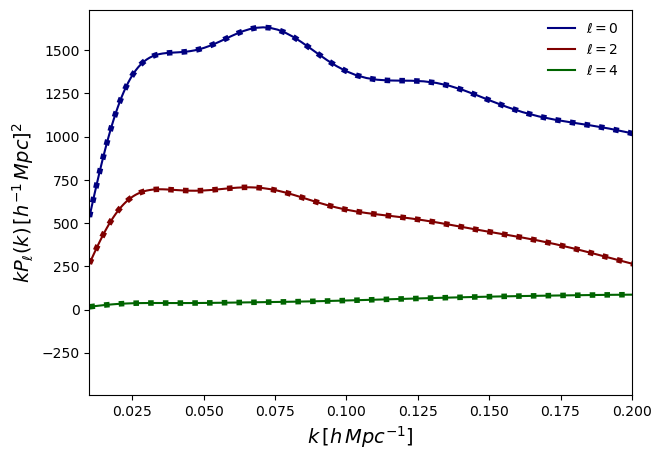

In [13]:
import matplotlib
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(7,5))
axs.set_xlabel(r'$k \, [h\, Mpc^{-1}]$', fontsize =  14)
axs.set_ylabel(r'$k P_{\ell}(k) \, [h^{-1} \,  Mpc]^2$', fontsize =  14)

axs.plot(k, k * P0, color = 'navy', ls='-', label=r'$\ell = 0$')
axs.plot(k, k * P2, color = 'maroon', ls='-', label=r'$\ell = 2$')
axs.plot(k, k * P4, color = 'darkgreen', ls='-', label=r'$\ell = 4$')


axs.plot(k, k * P0_marg, color = 'navy', ls=':', lw=4)
axs.plot(k, k * P2_marg, color = 'maroon', ls=':', lw=4)
axs.plot(k, k * P4_marg, color = 'darkgreen', ls=':', lw=4)

axs.set_xlim([k[0], 0.2])
#axs.set_ylim([-200.0, 1800])

leg1 = axs.legend(loc = 'best');
leg1.get_frame().set_linewidth(0.0);

plt.show()

## Bispectrum
Set the nuisance parameters for the bispectrum computation.  

In [14]:
#pars for Bispectrum
Pshot = 0; # This would be the same as PshopP*alphashot0 if the bispectrum were computed up to 1loop (I think!)
Bshot = 0;
c1=0
c2=0
X_FoG_bk=1

f0 = nonlinear.f0

bpars = [b1, b2, bs2, c1, c2, Bshot, Pshot, X_FoG_bk]

In [15]:
ks = np.logspace(np.log10(0.0001), np.log10(0.4), 30)
k1k2T = np.vstack([ks,ks]).T

Here you can select your preferred bispectrum basis: `sugiyama` or `scoccimarro` (the latter is not yet implemented).  
You can also choose your preferred model: `'EFT'`, `'FOLPSD'`, or `'TNS'`.  

In [16]:
bispectrum = BispectrumCalculator( model = 'FOLPSD')
bpars = bispectrum.set_bias_scheme(bpars, bias_scheme='folps') #Converting the given nuisances to the set of nuisances used by folps

In [17]:
k_pkl_pklnw = np.array([table[0], table[1], table_now[1]])

In [18]:
%%time
B000, B202 =  bispectrum.Sugiyama_Bell(f=f0,  bpars=bpars,
                                      k_pkl_pklnw=k_pkl_pklnw,
                                      k1k2pairs=k1k2T, qpar=1, qper=1, precision=[10,8,8], damping='lor',
                                        multipoles=['B000', 'B202'], renormalize=True, interpolation_method='linear', bias_scheme='folps',do_interp_bk=False,kout=None)

CPU times: user 2.69 ms, sys: 7.07 ms, total: 9.76 ms
Wall time: 10.2 ms


/global/homes/p/prakharb/FOLPS_JAX/folps/folps.py:161: RuntimeWarning: invalid value encountered in divide
  return np.where(x == 0, np.array(1.0, dtype=x.dtype), np.sin(x) / x)
/global/homes/p/prakharb/FOLPS_JAX/folps/folps.py:170: RuntimeWarning: divide by zero encountered in divide
  j2 = ( (3.0 / x2 - 1.0) * sinx / x ) - (3.0 * cosx / x2)
/global/homes/p/prakharb/FOLPS_JAX/folps/folps.py:170: RuntimeWarning: invalid value encountered in multiply
  j2 = ( (3.0 / x2 - 1.0) * sinx / x ) - (3.0 * cosx / x2)
/global/homes/p/prakharb/FOLPS_JAX/folps/tools.py:60: RuntimeWarning: divide by zero encountered in divide
  return np.where(np.asarray(where), h0 / h1, out)
/global/homes/p/prakharb/FOLPS_JAX/folps/tools.py:60: RuntimeWarning: invalid value encountered in divide
  return np.where(np.asarray(where), h0 / h1, out)
/global/homes/p/prakharb/FOLPS_JAX/folps/tools.py:60: RuntimeWarning: invalid value encountered in scalar divide
  return np.where(np.asarray(where), h0 / h1, out)


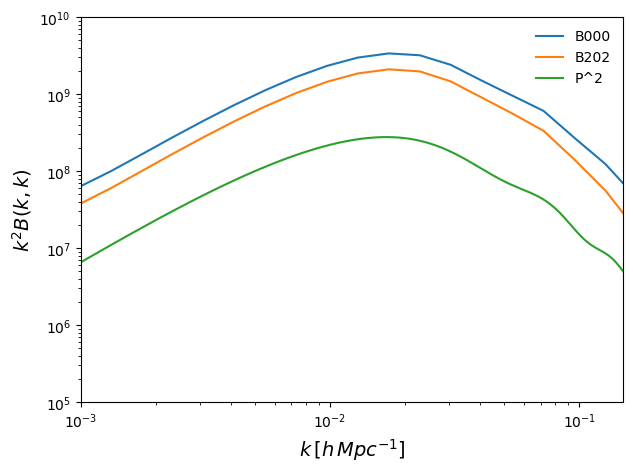

In [19]:
fig, axs = plt.subplots(figsize=(7,5))
axs.set_xlabel(r'$k \, [h\, Mpc^{-1}]$', fontsize =  14)
axs.set_ylabel(r'$k^2 B(k,k) $', fontsize =  14)



axs.loglog(k1k2T.T[0],B000, ls='-', label='B000')
axs.loglog(k1k2T.T[0],B202, ls='-', label='B202')
axs.loglog(nonlinear.inputpkT[0],nonlinear.inputpkT[1]*nonlinear.inputpkT[1], ls='-', label='P^2')



axs.set_xlim([0.001,0.15])
axs.set_ylim([1e5, 1e10])

leg1 = axs.legend(loc = 'best');
leg1.get_frame().set_linewidth(0.0);

plt.show()